In [82]:
import pandas as pd 

In [83]:
data = pd.read_csv('PaySim.csv', sep =',')

In [84]:
data

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


### EXPLORATORY DATA ANALYSIS (EDA)

In [85]:
### this display the count of rows and columns
data.shape

(6362620, 11)

In [86]:
### checking the data for nulls
data.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [87]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [88]:
data['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [89]:
data['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [90]:
# instead of letting pandas guess and default to wasteful 64-bit types
dtypes = {
    'step': 'int32',            # hour counter (1-743) — fits comfortably in 32-bit
    'type': 'category',         # only 5 repeating values (PAYMENT, CASH_OUT, etc.) — category avoids storing the string 6.36M times
    'amount': 'float64',        # transaction amount — keep full float precision for money values
    'nameOrig': 'str',          # sender ID like 'C1231006815' — text, not a number, so leave as string
    'oldbalanceOrg': 'float64', # sender's balance before the transaction
    'newbalanceOrig': 'float64',# sender's balance after the transaction
    'nameDest': 'str',          # recipient ID — text, same reasoning as nameOrig
    'oldbalanceDest': 'float64',# recipient's balance before the transaction
    'newbalanceDest': 'float64',# recipient's balance after the transaction
    'isFraud': 'int8',          # only ever 0 or 1 — int8 is the smallest type that fits
    'isFlaggedFraud': 'int8',   # same as isFraud — binary flag, int8 is enough
}

In [91]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [92]:
# this is to reduce the memory usage by converting each named column to the appropriate data type you 
data = data.astype({
    'step': 'int32',            # was int64 — shrink since values only go up to 743
    'type': 'category',         # was object (generic string) — category stores each of the 5 values once
    'nameOrig': 'str',          # already effectively string, but explicit is safer than 'object'
    'nameDest': 'str',          # same as above
    'isFraud': 'int8',          # was int64 — only holds 0 or 1, so int8 is plenty
    'isFlaggedFraud': 'int8',   # same reasoning as isFraud 
})

In [93]:
data

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [94]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int32   
 1   type            category
 2   amount          float64 
 3   nameOrig        object  
 4   oldbalanceOrg   float64 
 5   newbalanceOrig  float64 
 6   nameDest        object  
 7   oldbalanceDest  float64 
 8   newbalanceDest  float64 
 9   isFraud         int8    
 10  isFlaggedFraud  int8    
dtypes: category(1), float64(5), int32(1), int8(2), object(2)
memory usage: 382.3+ MB


In [95]:
# this is to check if duplicate rows exist in the whole dataset
data.duplicated().sum()

np.int64(0)

In [96]:
# this is to check how many columns are in the dataset
len(data.columns)

11

In [97]:
# this is to view the columns names in the dataset
data.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [98]:
# Validity checks: negative values & zero amounts
for col in ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']:
    negative_count = (data[col] < 0).sum()
    print(f"{col}: {negative_count} negative values")

amount: 0 negative values
oldbalanceOrg: 0 negative values
newbalanceOrig: 0 negative values
oldbalanceDest: 0 negative values
newbalanceDest: 0 negative values


In [99]:
# Understanding the merchant vs. customer destination pattern; nameDest starts with 'C' for customer accounts or 'M' for merchant accounts
# extracting just that first letter into a new column to analyze the split
data['destType'] = data['nameDest'].str[0]


In [100]:
# Cross-tabulate transaction type against destination type — this shows us 
# whether certain transaction types ONLY ever go to merchants or ONLY to customers
print(pd.crosstab(data['type'], data['destType']))

destType        C        M
type                      
CASH_IN   1399284        0
CASH_OUT  2237500        0
DEBIT       41432        0
PAYMENT         0  2151495
TRANSFER   532909        0


In [101]:
# Check whether merchant destinations always show 0 for both balance columns —
# PaySim never simulates merchant balances, so this should be True (not a data error)
merchant_rows = data[data['destType'] == 'M']
print("\noldbalanceDest always 0 for merchants?", (merchant_rows['oldbalanceDest'] == 0).all())
print("newbalanceDest always 0 for merchants?", (merchant_rows['newbalanceDest'] == 0).all())


oldbalanceDest always 0 for merchants? True
newbalanceDest always 0 for merchants? True


In [102]:
# Grouping Fraud rate by transaction type, then for isFraud calculate: sum (total fraud count), 
# count (total transactions), and mean (fraud rate as a decimal, since isFraud is 0/1)
fraud_by_type = data.groupby('type', observed=True)['isFraud'].agg(['sum', 'count', 'mean'])

In [103]:
# Convert the decimal mean into a readable percentage column
fraud_by_type['fraud_rate_%'] = fraud_by_type['mean'] * 100

print(fraud_by_type.sort_values('fraud_rate_%', ascending=False))

           sum    count      mean  fraud_rate_%
type                                           
TRANSFER  4097   532909  0.007688      0.768799
CASH_OUT  4116  2237500  0.001840      0.183955
CASH_IN      0  1399284  0.000000      0.000000
DEBIT        0    41432  0.000000      0.000000
PAYMENT      0  2151495  0.000000      0.000000


Evaluate the existing fraud-flagging system

In [104]:
# Cross-tabulate actual fraud (isFraud) against the system's own flag (isFlaggedFraud). Note: 1 means is Fraud, 0 means its not
# This tells us: of all the real fraud cases, how many did the existing system actually catch?
confusion = pd.crosstab(data['isFraud'], data['isFlaggedFraud'], rownames=['Actual Fraud'], colnames=['Flagged by System'])
print(confusion)

Flagged by System        0   1
Actual Fraud                  
0                  6354407   0
1                     8197  16


In [105]:
# Manually pull out the key numbers to compute recall (what % of real fraud got caught by the existing system)
true_fraud = data['isFraud'].sum()
caught_fraud = data[(data['isFraud'] == 1) & (data['isFlaggedFraud'] == 1)].shape[0]
recall_pct = (caught_fraud / true_fraud) * 100
print(f"\nExisting system caught {caught_fraud} of {true_fraud} actual frauds ({recall_pct:.2f}% recall)")


Existing system caught 16 of 8213 actual frauds (0.19% recall)


# Data Preprocessing

In [106]:
# to know the statistical distribution 
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [107]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [108]:
data.shape

(6362620, 12)

In [109]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 12 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int32   
 1   type            category
 2   amount          float64 
 3   nameOrig        object  
 4   oldbalanceOrg   float64 
 5   newbalanceOrig  float64 
 6   nameDest        object  
 7   oldbalanceDest  float64 
 8   newbalanceDest  float64 
 9   isFraud         int8    
 10  isFlaggedFraud  int8    
 11  destType        object  
dtypes: category(1), float64(5), int32(1), int8(2), object(3)
memory usage: 430.8+ MB


In [110]:
# Import plotting libraries — matplotlib is the base plotting engine,
# seaborn builds nicer statistical charts on top of it
import matplotlib.pyplot as plt
import seaborn as sns

In [111]:
# Derived hour-of-day from step, step is hours since simulation start, so step % 24 gives the hour within a day (0-23)
data['hourOfDay'] = data['step'] % 24

In [112]:
# ===== L1: the list of hours themselves (0 through 23) =====
L1 = sorted(data['hourOfDay'].unique())
# ===== L2: total transactions per hour =====
# groupby hourOfDay, count any column (size() counts rows per group) 
L2 = data.groupby('hourOfDay').size()
# ===== L3: fraud transactions per hour =====
# filter to only fraud rows first, then count per hour
L3 = data[data['isFraud'] == 1].groupby('hourOfDay').size()
# ===== L4: valid (non-fraud) transactions per hour =====
L4 = data[data['isFraud'] == 0].groupby('hourOfDay').size()
# Print them to see the raw numbers before plotting
print("Total transactions per hour:\n", L2)
print("\nFraud transactions per hour:\n", L3)

Total transactions per hour:
 hourOfDay
0      71587
1      27111
2       9018
3       2007
4       1241
5       1641
6       3420
7       8988
8      26915
9     283518
10    425729
11    445992
12    483418
13    468474
14    439653
15    416686
16    441612
17    439941
18    580509
19    647814
20    553728
21    247806
22    194555
23    141257
dtype: int64

Fraud transactions per hour:
 hourOfDay
0     300
1     358
2     372
3     326
4     274
5     366
6     358
7     328
8     368
9     341
10    375
11    324
12    339
13    346
14    353
15    341
16    345
17    353
18    343
19    342
20    340
21    347
22    351
23    323
dtype: int64


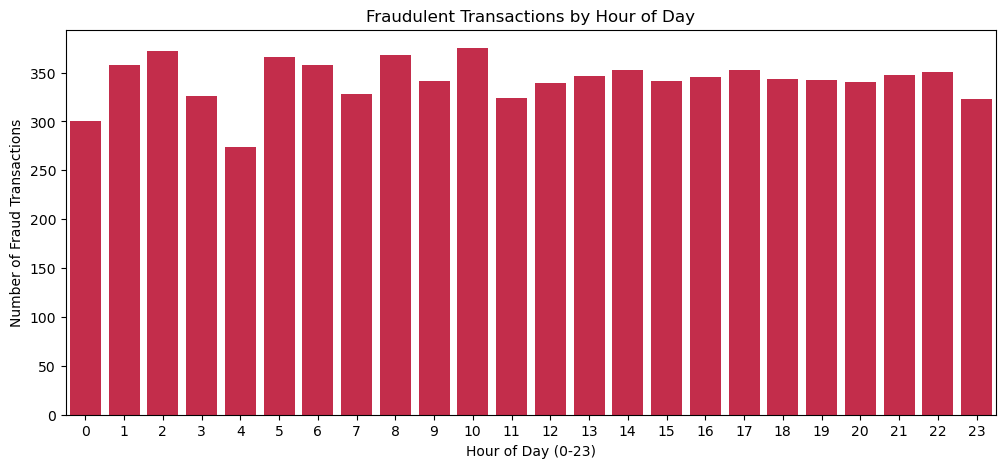

In [113]:
# ===== Plot 1: fraud transaction count by hour =====
plt.figure(figsize=(12, 5))
sns.barplot(x=L3.index, y=L3.values, color='crimson')
plt.title('Fraudulent Transactions by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Fraud Transactions')
plt.show()

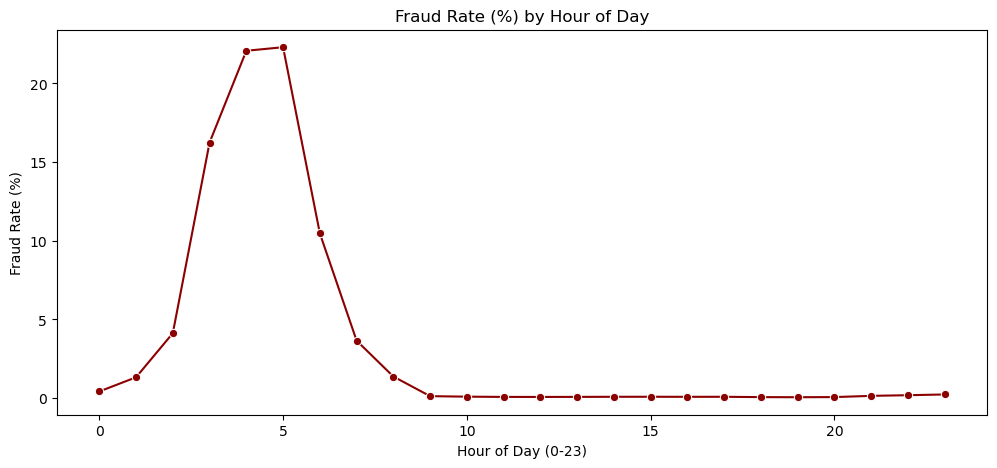

In [114]:
# ===== Plot 2: fraud RATE (not just count) by hour — often more revealing =====
# raw fraud counts can be misleading if some hours just have way more total volume —
# dividing fraud count by total count per hour shows the true risk concentration
fraud_rate_by_hour = (L3 / L2 * 100).fillna(0)
plt.figure(figsize=(12, 5))
sns.lineplot(x=fraud_rate_by_hour.index, y=fraud_rate_by_hour.values, marker='o', color='darkred')
plt.title('Fraud Rate (%) by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Fraud Rate (%)')
plt.show()

In [115]:
# Based on the chart, fraud rate spikes dramatically between hours 3-6 (inclusive) —
# turn that observed pattern into an explicit binary flag the model can use directly,
# rather than hoping it infers the pattern from raw hourOfDay alone
data['isHighRiskHour'] = data['hourOfDay'].between(3, 6).astype('int8')

# Confirm the flag captures what we saw in the chart
print(data.groupby('isHighRiskHour')['isFraud'].agg(['mean','count']))

                    mean    count
isHighRiskHour                   
0               0.001084  6354311
1               0.159345     8309


In [116]:
# ===== Balance "error" features =====
# In a normal, correctly-recorded transaction: oldbalanceOrg - amount should equal newbalanceOrig.
# When it DOESN'T, that mismatch itself is a signal — large mismatches are strongly 
# associated with fraud in PaySim (fraudsters often empty an account completely, 
# creating a bigger-than-expected balance jump). We turn that mismatch into a numeric feature.
data['errorBalanceOrig'] = data['oldbalanceOrg'] - data['amount'] - data['newbalanceOrig']
data['errorBalanceDest'] = data['oldbalanceDest'] + data['amount'] - data['newbalanceDest']

In [117]:
data

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,destType,hourOfDay,isHighRiskHour,errorBalanceOrig,errorBalanceDest
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,M,1,0,0.0,9.839640e+03
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,M,1,0,0.0,1.864280e+03
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,C,1,0,0.0,1.810000e+02
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0,C,1,0,0.0,2.136300e+04
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,M,1,0,0.0,1.166814e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0,C,23,0,0.0,0.000000e+00
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,C,23,0,0.0,6.311409e+06
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0,C,23,0,0.0,1.000000e-02
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0,C,23,0,0.0,8.500025e+05


In [118]:
# ===== Time-based features =====
# 'step' is hours since simulation start (1 to 743) — break it into more interpretable units
data['day'] = data['step'] // 24          # which day of the 31-day simulation (0-30)

In [119]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 17 columns):
 #   Column            Dtype   
---  ------            -----   
 0   step              int32   
 1   type              category
 2   amount            float64 
 3   nameOrig          object  
 4   oldbalanceOrg     float64 
 5   newbalanceOrig    float64 
 6   nameDest          object  
 7   oldbalanceDest    float64 
 8   newbalanceDest    float64 
 9   isFraud           int8    
 10  isFlaggedFraud    int8    
 11  destType          object  
 12  hourOfDay         int32   
 13  isHighRiskHour    int8    
 14  errorBalanceOrig  float64 
 15  errorBalanceDest  float64 
 16  day               int32   
dtypes: category(1), float64(7), int32(3), int8(3), object(3)
memory usage: 582.5+ MB


In [120]:
# ===== Balance depletion flags =====
# Fraud often involves draining an account to exactly zero — flag when that happens
data['origEmptiedOut'] = ((data['oldbalanceOrg'] > 0) & (data['newbalanceOrig'] == 0)).astype('int8')

In [121]:
# ===== Merchant destination flag (redundant with type, but explicit and model-friendly) =====
data['isMerchantDest'] = (data['destType'] == 'M').astype('int8')

In [122]:
data

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,destType,hourOfDay,isHighRiskHour,errorBalanceOrig,errorBalanceDest,day,origEmptiedOut,isMerchantDest
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,M,1,0,0.0,9.839640e+03,0,0,1
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,M,1,0,0.0,1.864280e+03,0,0,1
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,C,1,0,0.0,1.810000e+02,0,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0,C,1,0,0.0,2.136300e+04,0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,M,1,0,0.0,1.166814e+04,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0,C,23,0,0.0,0.000000e+00,30,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,C,23,0,0.0,6.311409e+06,30,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0,C,23,0,0.0,1.000000e-02,30,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0,C,23,0,0.0,8.500025e+05,30,1,0


In [123]:
# Quick sanity check: compare average errorBalanceOrig for fraud vs non-fraud transactions —
# if fraud transactions show a much bigger average error, this feature is doing real work
print(data.groupby('isFraud')['errorBalanceOrig'].mean())

isFraud
0   -201338.558109
1    -10692.325265
Name: errorBalanceOrig, dtype: float64


In [124]:
# ===== Hypothesis 1: oldbalanceOrg == 0 while amount > 0 is anomalous =====

data['zeroOrigBalanceAnomaly'] = (
    (data['oldbalanceOrg'] == 0) &
    (data['amount'] > 0)
).astype('int8')

check1 = (
    data[data['type'].isin(['CASH_OUT', 'TRANSFER'])]
    .groupby('zeroOrigBalanceAnomaly')['isFraud']
    .agg(['mean', 'count'])
)

print("Hypothesis 1 — zero orig balance anomaly vs fraud rate:")
print(check1)


# ===== Create analysis subset =====

subset = data[
    data['type'].isin(['CASH_OUT', 'TRANSFER'])
].copy()


# ===== Hypotheses 2 & 3: balance error features =====

subset['errorBalanceOrig'] = (
    subset['newbalanceOrig']
    + subset['amount']
    - subset['oldbalanceOrg']
)

subset['errorBalanceDest'] = (
    subset['oldbalanceDest']
    + subset['amount']
    - subset['newbalanceDest']
)

print(
    "\nHypothesis 2/3 — average balance error, "
    "fraud vs not (CASH_OUT/TRANSFER only):"
)

print(
    subset.groupby('isFraud')[
        ['errorBalanceOrig', 'errorBalanceDest']
    ].mean()
)


# ===== Hypothesis 4: recipient balance unchanged despite a nonzero transaction =====

subset['destBalanceUnchanged'] = (
    (subset['oldbalanceDest'] == subset['newbalanceDest']) &
    (subset['amount'] > 0)
).astype('int8')

check4 = (
    subset.groupby('destBalanceUnchanged')['isFraud']
    .agg(['mean', 'count'])
)

print(
    "\nHypothesis 4 — destination balance unchanged vs fraud rate:"
)

print(check4)

Hypothesis 1 — zero orig balance anomaly vs fraud rate:
                            mean    count
zeroOrigBalanceAnomaly                   
0                       0.005601  1461843
1                       0.000019  1308566

Hypothesis 2/3 — average balance error, fraud vs not (CASH_OUT/TRANSFER only):
         errorBalanceOrig  errorBalanceDest
isFraud                                    
0           286803.509954     -30910.325352
1            10692.325265     732509.301069

Hypothesis 4 — destination balance unchanged vs fraud rate:
                          mean    count
destBalanceUnchanged                   
0                     0.001499  2764633
1                     0.704640     5776


In [125]:
# Quick validation of origEmptiedOut before deciding to keep it —
# same pattern as destBalanceUnchanged, but on the SENDER side instead of receiver
data['origEmptiedOut'] = ((data['oldbalanceOrg'] > 0) & (data['newbalanceOrig'] == 0)).astype('int8')

check5 = data[data['type'].isin(['CASH_OUT','TRANSFER'])].groupby('origEmptiedOut')['isFraud'].agg(['mean','count'])
print("origEmptiedOut vs fraud rate:")
print(check5)

origEmptiedOut vs fraud rate:
                    mean    count
origEmptiedOut                   
0               0.000127  1582335
1               0.006744  1188074


In [126]:
data

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,destType,hourOfDay,isHighRiskHour,errorBalanceOrig,errorBalanceDest,day,origEmptiedOut,isMerchantDest,zeroOrigBalanceAnomaly
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,M,1,0,0.0,9.839640e+03,0,0,1,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,M,1,0,0.0,1.864280e+03,0,0,1,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,C,1,0,0.0,1.810000e+02,0,1,0,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0,C,1,0,0.0,2.136300e+04,0,1,0,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,M,1,0,0.0,1.166814e+04,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0,C,23,0,0.0,0.000000e+00,30,1,0,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,C,23,0,0.0,6.311409e+06,30,1,0,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0,C,23,0,0.0,1.000000e-02,30,1,0,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0,C,23,0,0.0,8.500025e+05,30,1,0,0


In [127]:
# ===== Validate origEmptiedOut before deciding to keep it =====
# (account had money, then was drained to exactly 0 — a common fraud pattern in theory)
subset = data[data['type'].isin(['CASH_OUT','TRANSFER'])]
check5 = subset.groupby('origEmptiedOut')['isFraud'].agg(['mean','count'])
print("origEmptiedOut vs fraud rate:")
print(check5)

origEmptiedOut vs fraud rate:
                    mean    count
origEmptiedOut                   
0               0.000127  1582335
1               0.006744  1188074


In [129]:
print(data.columns.tolist())

['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'destType', 'hourOfDay', 'isHighRiskHour', 'errorBalanceOrig', 'errorBalanceDest', 'day', 'origEmptiedOut', 'isMerchantDest', 'zeroOrigBalanceAnomaly']


### Data Modeling

In [130]:
# ===== Filter to CASH_OUT and TRANSFER only =====

data_model = data[
    data['type'].isin(['CASH_OUT', 'TRANSFER'])
].copy()


# ===== Create final engineered feature =====

# Recipient balance unchanged despite a non-zero transaction
data_model['destBalanceUnchanged'] = (
    (data_model['oldbalanceDest'] == data_model['newbalanceDest'])
    & (data_model['amount'] > 0)
).astype('int8')


# ===== One-hot encode transaction type =====

# CASH_OUT = 0
# TRANSFER = 1

data_model = pd.get_dummies(
    data_model,
    columns=['type'],
    drop_first=True
)


# ===== Final feature list =====

feature_cols = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'errorBalanceDest',
    'destBalanceUnchanged',
    'isHighRiskHour',
    'origEmptiedOut',
    'type_TRANSFER',
]


# ===== Verify all required features exist =====

missing_features = [
    col for col in feature_cols
    if col not in data_model.columns
]

if missing_features:
    raise ValueError(
        f"Missing required features: {missing_features}"
    )


# ===== Prepare model inputs =====

X = data_model[feature_cols]

y = data_model['isFraud']


# ===== Basic checks =====

print("X shape:", X.shape)
print("y shape:", y.shape)

print(
    "\nFraud rate in modeling set:",
    y.mean() * 100,
    "%"
)

print("\nFeature summary:")
print(X.describe())

X shape: (2770409, 10)
y shape: (2770409,)

Fraud rate in modeling set: 0.2964544224336551 %

Feature summary:
             amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
count  2.770409e+06   2.770409e+06    2.770409e+06    2.770409e+06   
mean   3.175361e+05   4.764308e+04    1.609190e+04    1.703551e+06   
std    8.877897e+05   2.513251e+05    1.512558e+05    4.225550e+06   
min    0.000000e+00   0.000000e+00    0.000000e+00    0.000000e+00   
25%    8.297354e+04   0.000000e+00    0.000000e+00    1.280734e+05   
50%    1.712609e+05   3.039600e+02    0.000000e+00    5.557100e+05   
75%    3.067912e+05   3.099700e+04    0.000000e+00    1.735900e+06   
max    9.244552e+07   5.958504e+07    4.958504e+07    3.560159e+08   

       newbalanceDest  errorBalanceDest  destBalanceUnchanged  isHighRiskHour  \
count    2.770409e+06      2.770409e+06          2.770409e+06    2.770409e+06   
mean     2.049734e+06     -2.864713e+04          2.084891e-03    1.020788e-03   
std      4.6769

In [139]:
# ===== Validate destination balance unchanged feature =====

check4 = (
    data_model
    .groupby('destBalanceUnchanged')['isFraud']
    .agg(['mean', 'count'])
)

print("Hypothesis 4 — destination balance unchanged vs fraud rate:")
print(check4)

Hypothesis 4 — destination balance unchanged vs fraud rate:
                          mean    count
destBalanceUnchanged                   
0                     0.001499  2764633
1                     0.704640     5776


In [140]:
# ===== Compare fraud rates =====

fraud_rate_unchanged = check4.loc[1, 'mean']
fraud_rate_changed = check4.loc[0, 'mean']

rate_multiple = fraud_rate_unchanged / fraud_rate_changed

print(
    f"\nFraud rate when destination balance is unchanged: "
    f"{fraud_rate_unchanged:.2%}"
)

print(
    f"Fraud rate when destination balance changes: "
    f"{fraud_rate_changed:.2%}"
)

print(
    f"Relative fraud-rate multiple: "
    f"{rate_multiple:.1f}x"
)


Fraud rate when destination balance is unchanged: 70.46%
Fraud rate when destination balance changes: 0.15%
Relative fraud-rate multiple: 470.2x


## Train and test 

In [141]:
from sklearn.model_selection import train_test_split

# stratify=y is critical here: fraud is only ~0.5% of this subset, so a plain random 
# split risks putting very few (or disproportionately many) fraud cases in the test set. 
# stratify=y forces both train and test sets to preserve the same fraud ratio as the full data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test — standard split
    random_state=42,    # fixes the randomness so your split is reproducible every run
    stratify=y
)

print("Train shape:", X_train.shape, "  Fraud rate:", y_train.mean() * 100, "%")
print("Test shape:", X_test.shape, "  Fraud rate:", y_test.mean() * 100, "%")

Train shape: (2216327, 10)   Fraud rate: 0.29643640130720783 %
Test shape: (554082, 10)   Fraud rate: 0.2965265069069199 %


### Importing Models/Libraries

In [142]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

In [143]:
!pip install xgboost

In [144]:
import xgboost as xgb

In [145]:
def bin_period(hour):
    if 0 <= hour <= 5:
        return 'Midnight/Early Hours (12am-6am)'
    elif 6 <= hour <= 11:
        return 'Morning (6am-12pm)'
    elif 12 <= hour <= 17:
        return 'Afternoon (12pm-6pm)'
    else:
        return 'Night (6pm-12am)'

data['dayPeriod'] = data['hourOfDay'].apply(bin_period)


                                     mean    count   sum  fraud_rate_%
dayPeriod                                                             
Midnight/Early Hours (12am-6am)  0.071121    28065  1996      7.112061
Morning (6am-12pm)               0.004034   519040  2094      0.403437
Night (6pm-12am)                 0.002047   999627  2046      0.204676
Afternoon (12pm-6pm)             0.001697  1223677  2077      0.169734


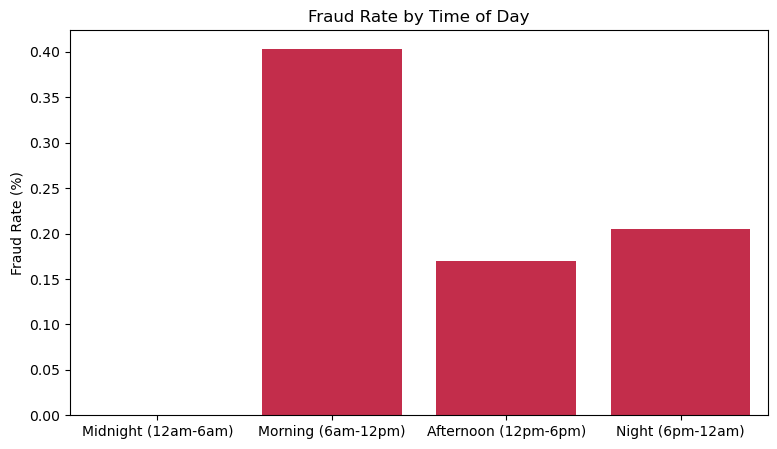

In [146]:
# Fraud rate by period, for the CASH_OUT/TRANSFER subset where fraud actually occurs
subset = data[data['type'].isin(['CASH_OUT','TRANSFER'])]
period_fraud = subset.groupby('dayPeriod')['isFraud'].agg(['mean','count','sum'])
period_fraud['fraud_rate_%'] = period_fraud['mean'] * 100
print(period_fraud.sort_values('fraud_rate_%', ascending=False))

# Visualize
plt.figure(figsize=(9,5))
order = ['Midnight (12am-6am)','Morning (6am-12pm)','Afternoon (12pm-6pm)','Night (6pm-12am)']
sns.barplot(x=period_fraud.reindex(order).index, y=period_fraud.reindex(order)['fraud_rate_%'], color='crimson')
plt.title('Fraud Rate by Time of Day')
plt.ylabel('Fraud Rate (%)')
plt.xlabel('')
plt.show()

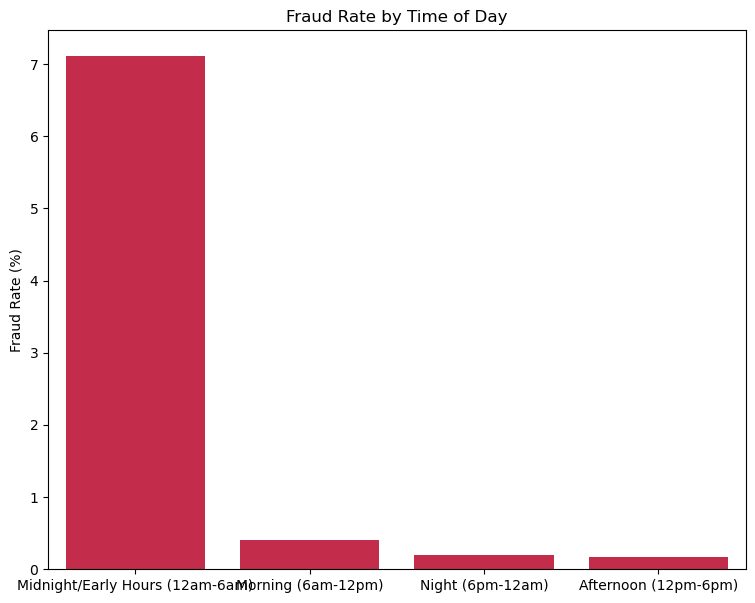

In [147]:
plt.figure(figsize=(9,7))
# Sort by fraud_rate_% directly instead of relying on a fixed label list —
# this can never go stale, since it always reads whatever labels currently exist
period_sorted = period_fraud.sort_values('fraud_rate_%', ascending=False)
sns.barplot(x=period_sorted.index, y=period_sorted['fraud_rate_%'], color='crimson')
plt.title('Fraud Rate by Time of Day')
plt.ylabel('Fraud Rate (%)')
plt.xlabel('')
plt.show()

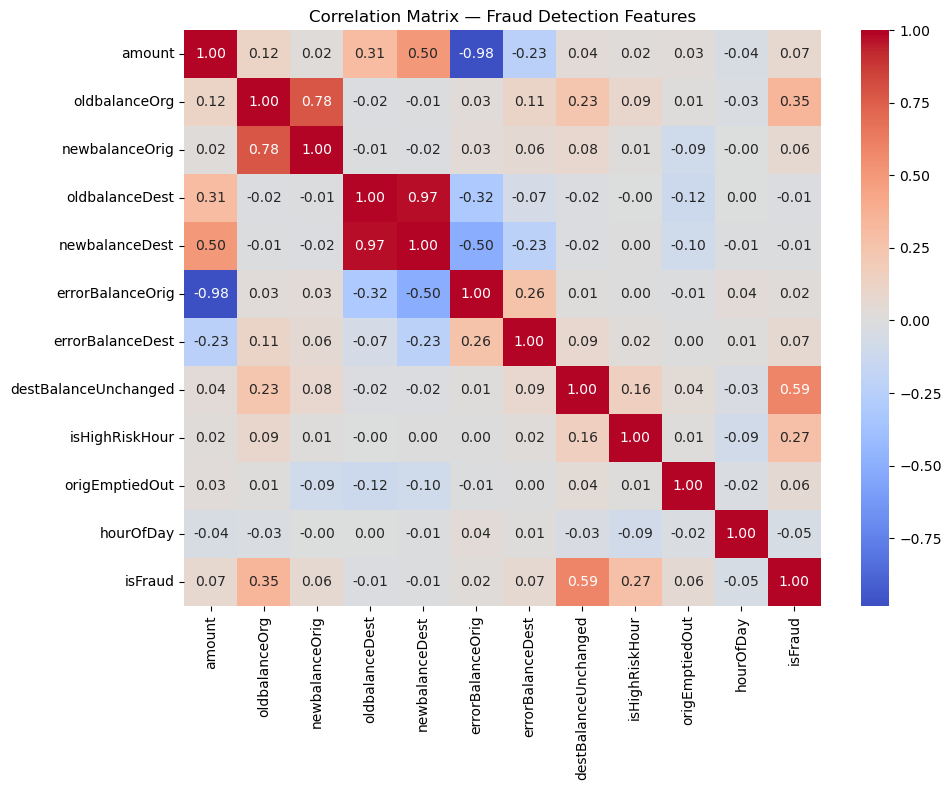

In [149]:
# ===== Pearson Correlation Analysis =====
# Pearson correlation is appropriate here because binary variables
# such as isFraud can be treated as 0/1 variables.

numeric_features = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'errorBalanceOrig',
    'errorBalanceDest',
    'destBalanceUnchanged',
    'isHighRiskHour',
    'origEmptiedOut',
    'hourOfDay',
    'isFraud'
]

# Use data_model because it contains the final engineered features
corr_matrix = data_model[numeric_features].corr()

# Full correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix — Fraud Detection Features")
plt.tight_layout()
plt.show()

## Correlation Analysis — Interpretation

**Confirms two earlier findings, quantifies them formally:**
- `destBalanceUnchanged`: 0.590 correlation with isFraud — by far the strongest, 
  consistent with the 470x fraud-rate jump found earlier. Both methods agree.
- `isHighRiskHour`: 0.274 correlation — consistent with the 147x fraud-rate jump 
  found in the hour analysis. Both methods agree.

**A new finding this analysis surfaced:**
- `oldbalanceOrg`: 0.348 correlation — moderately strong, and not something we'd 
  isolated before. This formally confirms what Hypothesis 1 showed indirectly: 
  accounts with money in them are far more likely to be targeted for fraud than 
  empty accounts. Worth adding to the report as a named insight.

**A caveat, not a contradiction:**
- `errorBalanceDest` shows a surprisingly WEAK correlation (0.070) despite the huge 
  gap we found earlier in average values (-30,910 for legitimate vs +732,509 for 
  fraud). This is not a contradiction — it's a limitation of correlation itself. 
  Pearson correlation assumes a roughly straight-line relationship and is sensitive 
  to outliers; a small number of extreme fraud cases can produce a large average 
  gap without a strong linear correlation across the full dataset. We keep 
  `errorBalanceDest` in the feature set regardless — Random Forest and XGBoost 
  don't assume linearity and are likely to extract real signal from it that 
  correlation alone doesn't capture.

**Validates an earlier decision:**
- `amount` and `errorBalanceOrig` correlate at 0.98 — nearly identical. This confirms 
  dropping `errorBalanceOrig` earlier was the right call for a second reason beyond 
  its weak fraud signal: it was almost entirely redundant with `amount`, which we 
  already keep.

In [150]:
# ===== Logistic Regression needs scaled features (it's distance/coefficient-based) =====
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only, to avoid leaking test data info
X_test_scaled = scaler.transform(X_test)        # apply the SAME scaling to test, don't re-fit

In [153]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, average_precision_score, roc_auc_score

# This list collects one row per model as you train them — run this ONCE now,
# don't re-run it later or you'll wipe out earlier results
results = []

def evaluate_and_store(label, y_true, y_pred, y_proba):
    # Prints full detail for this one model
    print(f"\n===== {label} =====")
    print(classification_report(y_true, y_pred, target_names=['Not Fraud','Fraud']))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    
    # Also stores a summary row for the running comparison table
    results.append({
        'Model': label,
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'PR-AUC': average_precision_score(y_true, y_proba),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
    })
    
    # Print the table as it stands so far — grows by one row each time you run a model
    print("\n--- Comparison so far ---")
    print(pd.DataFrame(results))

In [154]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# LR needs scaled features — fit the scaler on train only, apply to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

evaluate_and_store('LR', y_test, lr_pred, lr_proba)


===== LR =====
              precision    recall  f1-score   support

   Not Fraud       1.00      0.98      0.99    552439
       Fraud       0.11      0.95      0.20      1643

    accuracy                           0.98    554082
   macro avg       0.56      0.97      0.59    554082
weighted avg       1.00      0.98      0.99    554082

Confusion Matrix:
 [[539800  12639]
 [    77   1566]]

--- Comparison so far ---
  Model  Precision    Recall        F1    PR-AUC  ROC-AUC
0    LR   0.110243  0.953135  0.197627  0.758432  0.99415


In [163]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # tree models use raw, unscaled features

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

evaluate_and_store('RF', y_test, rf_pred, rf_proba)


===== RF =====
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    552439
       Fraud       0.97      0.81      0.88      1643

    accuracy                           1.00    554082
   macro avg       0.98      0.90      0.94    554082
weighted avg       1.00      1.00      1.00    554082

Confusion Matrix:
 [[552395     44]
 [   316   1327]]

--- Comparison so far ---
  Model  Precision    Recall        F1    PR-AUC   ROC-AUC
0    LR   0.110243  0.953135  0.197627  0.758432  0.994150
1    RF   0.967907  0.807669  0.880557  0.946250  0.994899
2   XGB   0.262300  0.979915  0.413829  0.529837  0.986371
3    RF   0.967907  0.807669  0.880557  0.946250  0.994899
4    RF   0.967907  0.807669  0.880557  0.946250  0.994899


In [156]:
import xgboost as xgb  # if this errors: !pip install xgboost

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='aucpr', random_state=42)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

evaluate_and_store('XGB', y_test, xgb_pred, xgb_proba)


===== XGB =====
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      1.00    552439
       Fraud       0.26      0.98      0.41      1643

    accuracy                           0.99    554082
   macro avg       0.63      0.99      0.70    554082
weighted avg       1.00      0.99      0.99    554082

Confusion Matrix:
 [[547911   4528]
 [    33   1610]]

--- Comparison so far ---
  Model  Precision    Recall        F1    PR-AUC   ROC-AUC
0    LR   0.110243  0.953135  0.197627  0.758432  0.994150
1    RF   0.967907  0.807669  0.880557  0.946250  0.994899
2   XGB   0.262300  0.979915  0.413829  0.529837  0.986371


## Recall matters most if SIDONPAY's priority is catching every fraud case, even at the cost of occasionally flagging a legitimate transaction. Precision matters most if the priority is minimizing customer friction (fewer legitimate transactions wrongly blocked). PR-AUC is the fairest single number for comparing models overall under severe imbalance.

### Random Forest was selected as SIDONPAY's fraud detection model because it achieved the best balance between catching fraud and avoiding false alarms — the exact trade-off the business needs. It correctly identifies 81% of all fraudulent transactions while maintaining 97% precision, meaning almost every transaction it flags is genuinely fraudulent. This minimizes both direct financial loss from missed fraud and customer frustration from wrongly blocked legitimate transactions. Logistic Regression and XGBoost both caught more fraud (95–98% recall) but at the cost of flagging 4–9x more legitimate transactions as fraudulent, which would be operationally unworkable at SIDONPAY's transaction volume.

                feature  importance
1         oldbalanceOrg    0.363235
0                amount    0.151199
8        origEmptiedOut    0.139656
6  destBalanceUnchanged    0.107421
4        newbalanceDest    0.083018
5      errorBalanceDest    0.044890
3        oldbalanceDest    0.035135
9         type_TRANSFER    0.030038
2        newbalanceOrig    0.026287
7        isHighRiskHour    0.019120


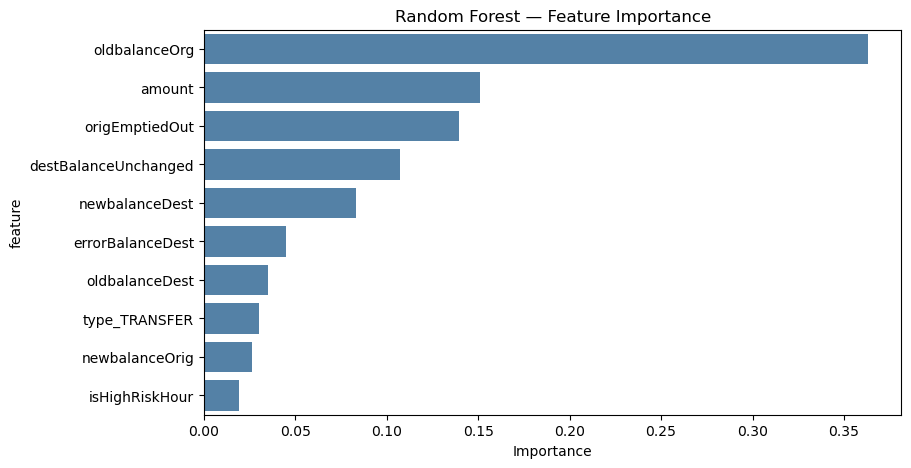

In [157]:
# RF exposes which features it actually relied on to split decisions —
# this is a NONLINEAR view, unlike Pearson correlation, so it can catch 
# signal that correlation missed (e.g. errorBalanceDest, which correlated weakly)
importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importances)

plt.figure(figsize=(9,5))
sns.barplot(x=importances['importance'], y=importances['feature'], color='steelblue')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance')
plt.show()

Default threshold: 0.50  ->  Precision: 0.968, Recall: 0.808, F1: 0.881
Best threshold:     0.430  ->  Precision: 0.955, Recall: 0.826, F1: 0.886


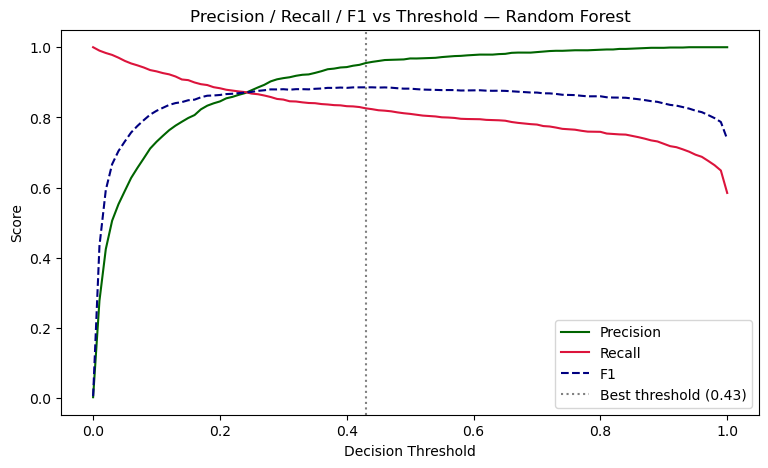


Confusion Matrix at tuned threshold:
[[552375     64]
 [   286   1357]]


In [158]:
from sklearn.metrics import precision_recall_curve

# precision_recall_curve tries every possible threshold and reports precision/recall at each —
# rf_proba already holds RF's fraud probability per test transaction from Step 10b
precisions, recalls, thresholds = precision_recall_curve(y_test, rf_proba)

# F1 at every threshold, so we can find the one that maximizes the balance we care about
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)  # +1e-10 avoids divide-by-zero
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Default threshold: 0.50  ->  Precision: {precision_score(y_test, rf_pred):.3f}, Recall: {recall_score(y_test, rf_pred):.3f}, F1: {f1_score(y_test, rf_pred):.3f}")
print(f"Best threshold:     {best_threshold:.3f}  ->  Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}")

# Visualize the trade-off — this plot is genuinely useful in the report to show 
# WHY a particular threshold was chosen, not just that it was
plt.figure(figsize=(9,5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='darkgreen')
plt.plot(thresholds, recalls[:-1], label='Recall', color='crimson')
plt.plot(thresholds, f1_scores[:-1], label='F1', color='navy', linestyle='--')
plt.axvline(best_threshold, color='gray', linestyle=':', label=f'Best threshold ({best_threshold:.2f})')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold — Random Forest')
plt.legend()
plt.show()

# Apply the new threshold and see the actual confusion matrix it produces
rf_pred_tuned = (rf_proba >= best_threshold).astype(int)
print("\nConfusion Matrix at tuned threshold:")
print(confusion_matrix(y_test, rf_pred_tuned))

In [159]:
import joblib

# Save the trained Random Forest model itself
joblib.dump(rf, 'fraud_model.pkl')

# Save the feature list and order — Streamlit's input form must build features 
# in this EXACT order later, since RF expects columns in the order it was trained on
joblib.dump(feature_cols, 'feature_cols.pkl')

# Save the tuned threshold — without this, anyone reusing the model would 
# default back to 0.5 and lose the F1 improvement we just found
joblib.dump(best_threshold, 'best_threshold.pkl')

print("Saved: fraud_model.pkl, feature_cols.pkl, best_threshold.pkl")
print(f"Remember: use threshold {best_threshold:.3f}, not the default 0.5, when predicting later")

Saved: fraud_model.pkl, feature_cols.pkl, best_threshold.pkl
Remember: use threshold 0.430, not the default 0.5, when predicting later


### Github rejected the upload of the trained model (fraud.model.pkl) so it needs to be compressed 

In [160]:
# Save the trained Random Forest model with compression

joblib.dump(
    rf,
    "fraud_model_compressed.pkl",
    compress=3)

['fraud_model_compressed.pkl']

In [161]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [164]:
X = data_model[feature_cols]
y = data_model["isFraud"]

In [165]:
joblib.dump(feature_cols, "feature_cols.pkl")

['feature_cols.pkl']

In [166]:
feature_cols = joblib.load("feature_cols.pkl")

In [167]:
best_threshold = joblib.load("best_threshold.pkl")

In [168]:
joblib.dump(best_threshold, "best_threshold.pkl")

['best_threshold.pkl']